# Goal

- we want to dissect the images with streets in the middle from the rest
- we also only want one image per street


**Steps**
1. Split 360 degree image into 36 images (10° Offset per step and image width is ... °)
2. Get depth map per image
3. Calculate center of depth per image
4. Map the centers per image on polar coordinate system and cluster them
- create ring graph
- remove the largest edges
- until each edge is less than offset
- then remove clusters with less than (0.5 * width/offset) points
5. return images 


# Functions

In [3]:
from cropping_panorama import *

/Users/lukasappel/Documents/HTW-Studium/Applied Artificial Intelligence/Projekt/AAIProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
segmentation_model = StreetSegmentationModel()
depth_model = DepthEstimationModel()

Using Apple Silicon MPS (Metal) for acceleration.


/Users/lukasappel/Documents/HTW-Studium/Applied Artificial Intelligence/Projekt/AAIProject/.venv/lib/python3.13/site-packages/transformers/image_processing_base.py:370: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Loading weights: 100%|██████████| 380/380 [00:00<00:00, 1846.69it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]            


Using Apple Silicon MPS for Depth Estimation.


The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 287/287 [00:00<00:00, 2166.15it/s, Materializing param=neck.reassemble_stage.layers.3.resize.weight]                  


In [ ]:
# import numpy as np
# import cv2

# def extract_perspective(equi_image, yaw, pitch, fov, width=600, height=600):
#     """
#     Extracts a planar perspective image from an equirectangular 360 panorama.
    
#     Parameters:
#     - equi_image: The original 360 image (numpy array from cv2.imread).
#     - yaw: The horizontal viewing angle in degrees (-180 to 180).
#     - pitch: The vertical viewing angle in degrees (0 is straight ahead).
#     - fov: The horizontal Field of View in degrees (e.g., 90).
#     - width, height: The dimensions of the output image.
#     """
#     # 1. Convert angles from degrees to radians
#     yaw_rad = np.radians(yaw)
#     pitch_rad = np.radians(pitch)
#     fov_rad = np.radians(fov)
    
#     equi_h, equi_w = equi_image.shape[:2]
    
#     # 2. Calculate the focal length
#     f = (width / 2.0) / np.tan(fov_rad / 2.0)
    
#     # 3. Create a grid of x, y coordinates for the output image
#     x, y = np.meshgrid(np.arange(width), np.arange(height))
    
#     # Center the coordinates around 0,0
#     x = x - width / 2.0
#     y = y - height / 2.0
#     z = np.full_like(x, f) # Depth is the focal length
    
#     # 4. Create 3D rays (stack x, y, z into a single array)
#     rays = np.stack((x, y, z), axis=-1)
    
#     # 5. Build rotation matrices for pitch (X-axis) and yaw (Y-axis)
#     Rx = np.array([
#         [1, 0, 0],
#         [0, np.cos(pitch_rad), -np.sin(pitch_rad)],
#         [0, np.sin(pitch_rad), np.cos(pitch_rad)]
#     ])
    
#     Ry = np.array([
#         [np.cos(yaw_rad), 0, np.sin(yaw_rad)],
#         [0, 1, 0],
#         [-np.sin(yaw_rad), 0, np.cos(yaw_rad)]
#     ])
    
#     # Combine rotations (Yaw then Pitch)
#     R = Ry @ Rx
    
#     # 6. Apply rotation to our 3D rays
#     # Flatten the rays for matrix multiplication, then reshape back
#     rays_flat = rays.reshape(-1, 3)
#     rotated_rays_flat = rays_flat @ R.T
#     rotated_rays = rotated_rays_flat.reshape(height, width, 3)
    
#     rx, ry, rz = rotated_rays[:, :, 0], rotated_rays[:, :, 1], rotated_rays[:, :, 2]
    
#     # 7. Convert the rotated 3D rays into spherical coordinates (Longitude, Latitude)
#     theta = np.arctan2(rx, rz)
#     phi = np.arcsin(ry / np.linalg.norm(rotated_rays, axis=-1))
    
#     # 8. Map the spherical coordinates to the equirectangular image pixels
#     # Map theta [-pi, pi] to [0, equi_w - 1]
#     map_x = (theta / (2 * np.pi) + 0.5) * (equi_w - 1)
#     # Map phi [-pi/2, pi/2] to [0, equi_h - 1]
#     map_y = (phi / np.pi + 0.5) * (equi_h - 1)
    
#     # 9. Sample the pixels using OpenCV's remap function
#     # BORDER_WRAP allows the image to seamlessly wrap around the 360-degree edges
#     planar_image = cv2.remap(
#         equi_image, 
#         map_x.astype(np.float32), 
#         map_y.astype(np.float32), 
#         interpolation=cv2.INTER_LINEAR,
#         borderMode=cv2.BORDER_WRAP 
#     )
    
#     return planar_image

In [ ]:
# import numpy as np
# import cv2
# from scipy.signal import find_peaks
# from scipy.ndimage import gaussian_filter1d

# def find_circular_peaks(profile, distance, prominence):
#     """
#     Finds peaks in a circular 1D array.
#     """
#     W = len(profile)
#     extended_profile = np.tile(profile, 3)
#     extended_peaks, _ = find_peaks(
#         extended_profile, 
#         distance=distance, 
#         prominence=prominence
#     )
#     valid_peaks = []
#     for p in extended_peaks:
#         if W <= p < 2 * W:
#             valid_peaks.append(p % W)
#     return np.array(valid_peaks)

# def find_street_angles(road_mask):
#     """
#     Analyzes a binary road mask to find the yaw angles of street entrances.
#     """
#     H, W = road_mask.shape
    
#     # find the 
#     # road_mask is 1 for road, 0 otherwise. 
#     # uses argmax to get the index of the highest mark in a column
#     # if a clumn contains no 1, then its highest peak should be at the bottom
#     road_pixels_exist = np.any(road_mask, axis=0)
#     top_road_y = np.argmax(road_mask, axis=0)
#     top_road_y[~road_pixels_exist] = H 
    
#     # inverts the profile at the x-axis
#     horizon_profile = H - top_road_y
    
#     # smoothing of the curve
#     smoothed_profile = gaussian_filter1d(horizon_profile, sigma=W/100)
#     plt.plot(smoothed_profile)

#     peaks = find_circular_peaks(smoothed_profile, distance=W//16, prominence=H//200)
    
#     # converts the coordinates back to angles
#     yaws = [(x / W) * 360.0 - 180.0 for x in peaks]
    
#     return yaws

# def extract_street_views(equi_image, yaws):
#     """
#     Main pipeline to find streets and extract them.
#     """
#     extracted_images = []
#     print(f"Found {len(yaws)} street entrances at angles: {yaws}")
#     for yaw in yaws:
#         planar_image = extract_perspective(equi_image, yaw=yaw, pitch=0, fov=90, width=600, height=600)
#         extracted_images.append(planar_image)
        
#     return extracted_images

In [ ]:
# import matplotlib.pyplot as plt
# import cv2

# def display_extracted_streets(images, yaws=None):
#     """
#     Displays a list of extracted street view images using matplotlib.
#     Automatically converts OpenCV BGR format to Matplotlib RGB format.
    
#     Parameters:
#     - images: List of numpy arrays (the extracted 600x600 images).
#     - yaws: Optional list of angles corresponding to the images for titles.
#     """
#     num_images = len(images)
    
#     if num_images == 0:
#         print("No images to display.")
#         return

#     # Create a dynamic figure size based on the number of extracted streets
#     # 5 inches per image width, 5 inches tall
#     fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    
#     # If there's only one street found, matplotlib doesn't return an array of axes. 
#     if num_images == 1:
#         axes = [axes]

#     for i, ax in enumerate(axes):
#         # Convert BGR (OpenCV) to RGB (Matplotlib)
#         img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        
#         # Display the image
#         ax.imshow(img_rgb)
#         ax.axis('off')
#         if yaws and i < len(yaws):
#             ax.set_title(f"Street View {i+1}\n(Angle: {yaws[i]:.1f}°)")
#         else:
#             ax.set_title(f"Street View {i+1}")
#     plt.tight_layout()
#     plt.show()

In [1]:
panorama_path = "./streetview_panoramas/61efb4ce-cdf2-4160-aaf6-f5bca9c7e247.jpg"
img = cv2.imread(panorama_path)
depth_map = depth_model.predict(img) 
angles = find_street_angles(depth_map)
street_images = extract_street_views(img, angles)
display_extracted_streets(street_images, angles)

NameError: name 'cv2' is not defined

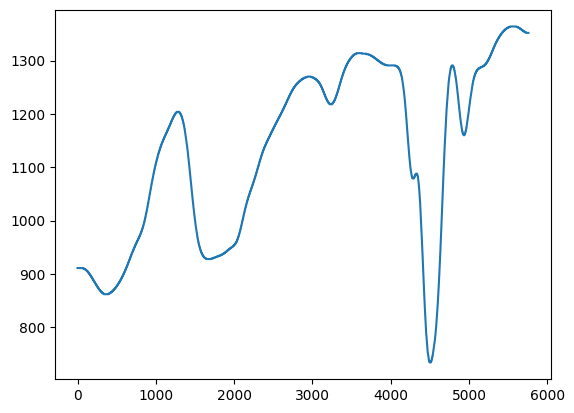

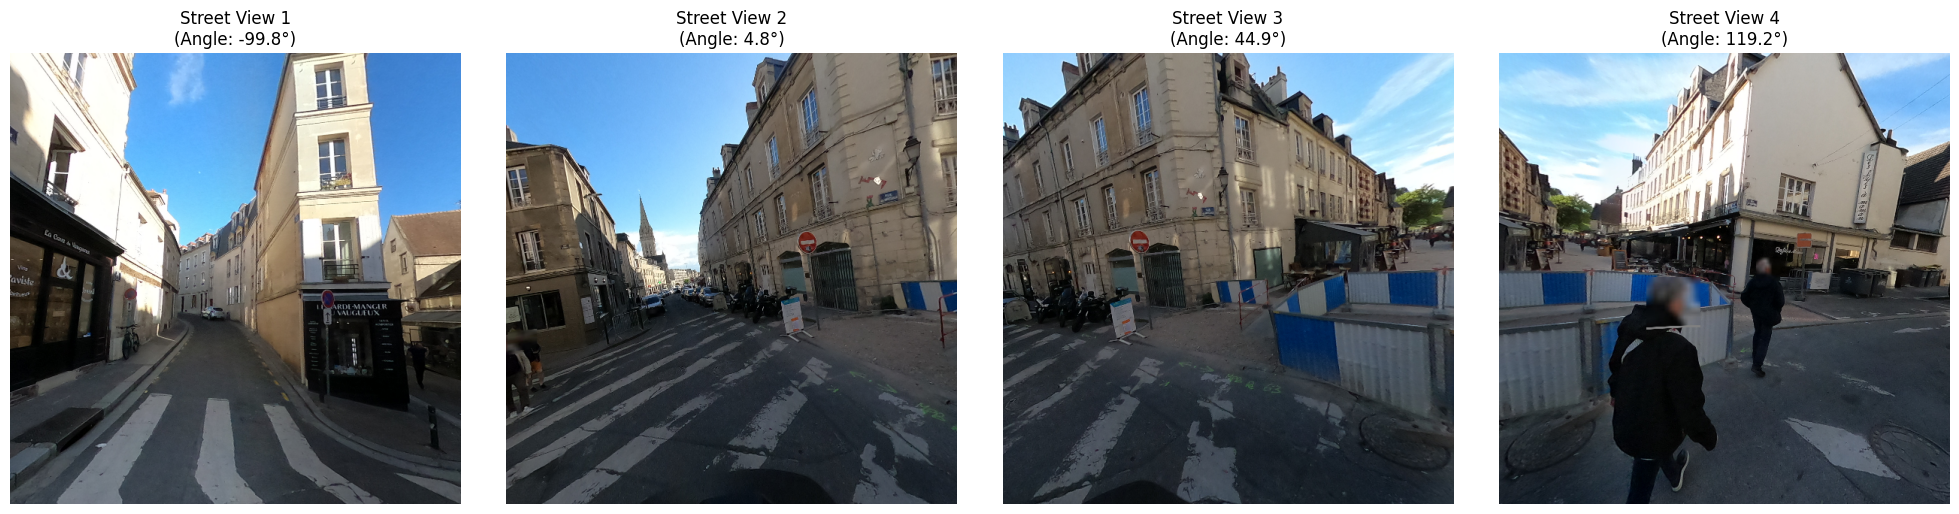

In [ ]:
yaws = find_street_angles(depth_map)
display_extracted_streets(street_images, yaws)

In [ ]:
# import torch
# import numpy as np
# from PIL import Image
# from transformers import AutoImageProcessor, AutoModelForDepthEstimation

# class DepthEstimationModel:
#     def __init__(self):
#         if torch.backends.mps.is_available():
#             self.device = torch.device("mps")
#             print("Using Apple Silicon MPS for Depth Estimation.")
#         else:
#             self.device = torch.device("cpu")
#         # Load the lightweight Depth Anything model
#         model_name = "LiheYoung/depth-anything-small-hf"
#         self.processor = AutoImageProcessor.from_pretrained(model_name)
#         self.model = AutoModelForDepthEstimation.from_pretrained(model_name).to(self.device)
#         self.model.eval()

#     def predict(self, image_input):
#         """Generates a depth map from an image."""
#         if isinstance(image_input, str):
#             image = Image.open(image_input).convert("RGB")
#         else:
#             image = Image.fromarray(image_input[..., ::-1]) # Convert OpenCV BGR to RGB

#         inputs = self.processor(images=image, return_tensors="pt")
#         inputs = {k: v.to(self.device) for k, v in inputs.items()}

#         with torch.no_grad():
#             outputs = self.model(**inputs)
#             predicted_depth = outputs.predicted_depth

#         # Resize the output depth map to match the original image dimensions
#         depth_map = torch.nn.functional.interpolate(
#             predicted_depth.unsqueeze(1),
#             size=image.size[::-1],
#             mode="bicubic",
#             align_corners=False,
#         ).squeeze().cpu().numpy()

#         return depth_map

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

def compare_street_detection(image, road_mask, depth_map):
    """
    Plots the original image alongside the 1D profiles and detected peaks 
    from both the Semantic Segmentation and Depth Estimation approaches.
    """
    H, W = image.shape[:2]
    
    # ==========================================
    # 1. Calculate Segmentation Profile & Peaks
    # ==========================================
    # Clean the mask
    kernel = np.ones((15, 15), np.uint8) 
    clean_mask = cv2.morphologyEx(road_mask, cv2.MORPH_CLOSE, kernel)
    
    # Find horizon profile
    road_pixels_exist = np.any(clean_mask, axis=0)
    top_road_y = np.argmax(clean_mask, axis=0)
    top_road_y[~road_pixels_exist] = H 
    horizon_profile = H - top_road_y
    
    # Smooth and find peaks
    seg_profile = gaussian_filter1d(horizon_profile, sigma=W/200)
    seg_peaks = find_circular_peaks(seg_profile, distance=W//12, prominence=np.max(seg_profile) * 0.1)
    
    # ==========================================
    # 2. Calculate Depth Profile & Peaks
    # ==========================================
    # Crop to horizon band
    top_crop = int(H * 0.35)
    bottom_crop = int(H * 0.65)
    horizon_band = depth_map[top_crop:bottom_crop, :]
    
    # Average and invert
    column_depths = np.mean(horizon_band, axis=0)
    max_depth_val = np.max(column_depths)
    inverted_profile = max_depth_val - column_depths
    
    # Smooth and find peaks
    depth_profile = gaussian_filter1d(inverted_profile, sigma=W/150)
    depth_peaks= find_circular_peaks(depth_profile, distance=W//12, prominence=np.max(depth_profile) * 0.1)

    # ==========================================
    # 3. Plotting the Comparison
    # ==========================================
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # --- Plot 1: Original Image with overlaid lines ---
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    ax1.imshow(img_rgb)
    ax1.set_title("Original 360° Image with Detected Streets")
    ax1.axis('off')
    
    # Draw vertical lines for Segmentation (Blue)
    for i, p in enumerate(seg_peaks):
        label = 'Segmentation (Road Mask)' if i == 0 else ""
        ax1.axvline(x=p, color='blue', linestyle='--', linewidth=2, label=label)
        
    # Draw vertical lines for Depth (Red)
    for i, p in enumerate(depth_peaks):
        label = 'Depth Estimation' if i == 0 else ""
        ax1.axvline(x=p, color='red', linestyle='-', linewidth=2, label=label)
        
    ax1.legend(loc='upper right')

    # --- Plot 2: Segmentation Profile ---
    ax2.plot(seg_profile, color='blue', label='Smoothed Horizon Profile')
    ax2.plot(seg_peaks, seg_profile[seg_peaks], "x", color='black', markersize=10, markeredgewidth=3, label='Detected Peaks')
    ax2.set_title("Semantic Segmentation: 1D Horizon Profile")
    ax2.set_ylabel("Pixel Height (from bottom)")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right')

    # --- Plot 3: Depth Profile ---
    ax3.plot(depth_profile, color='red', label='Smoothed Depth Profile (Inverted)')
    ax3.plot(depth_peaks, depth_profile[depth_peaks], "x", color='black', markersize=10, markeredgewidth=3, label='Detected Peaks')
    ax3.set_title("Depth Estimation: 1D Depth Profile")
    ax3.set_xlabel("Image Width (Pixels / Angles)")
    ax3.set_ylabel("Relative Depth (Inverted)")
    ax3.grid(True, linestyle=':', alpha=0.6)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

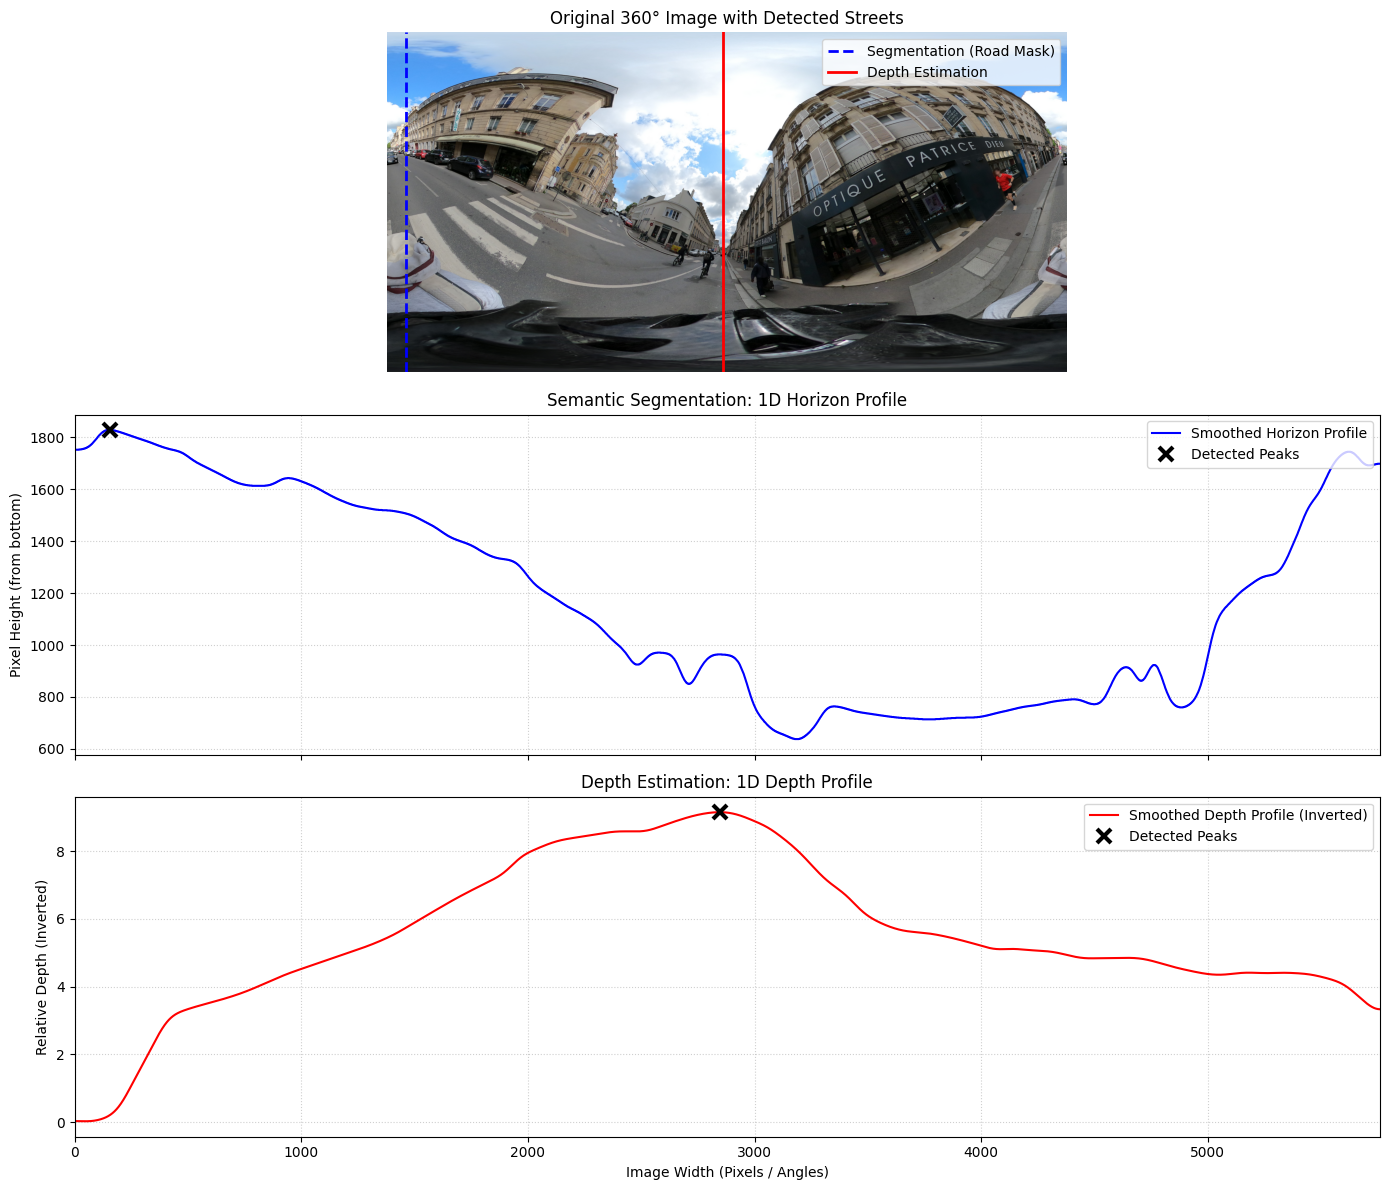

In [7]:
panorama_path = "./streetview_panoramas/6f34a62d-c8be-429d-b266-b1aca354ae1d.jpg"
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

In [ ]:
find_street_angles(seg_mask)

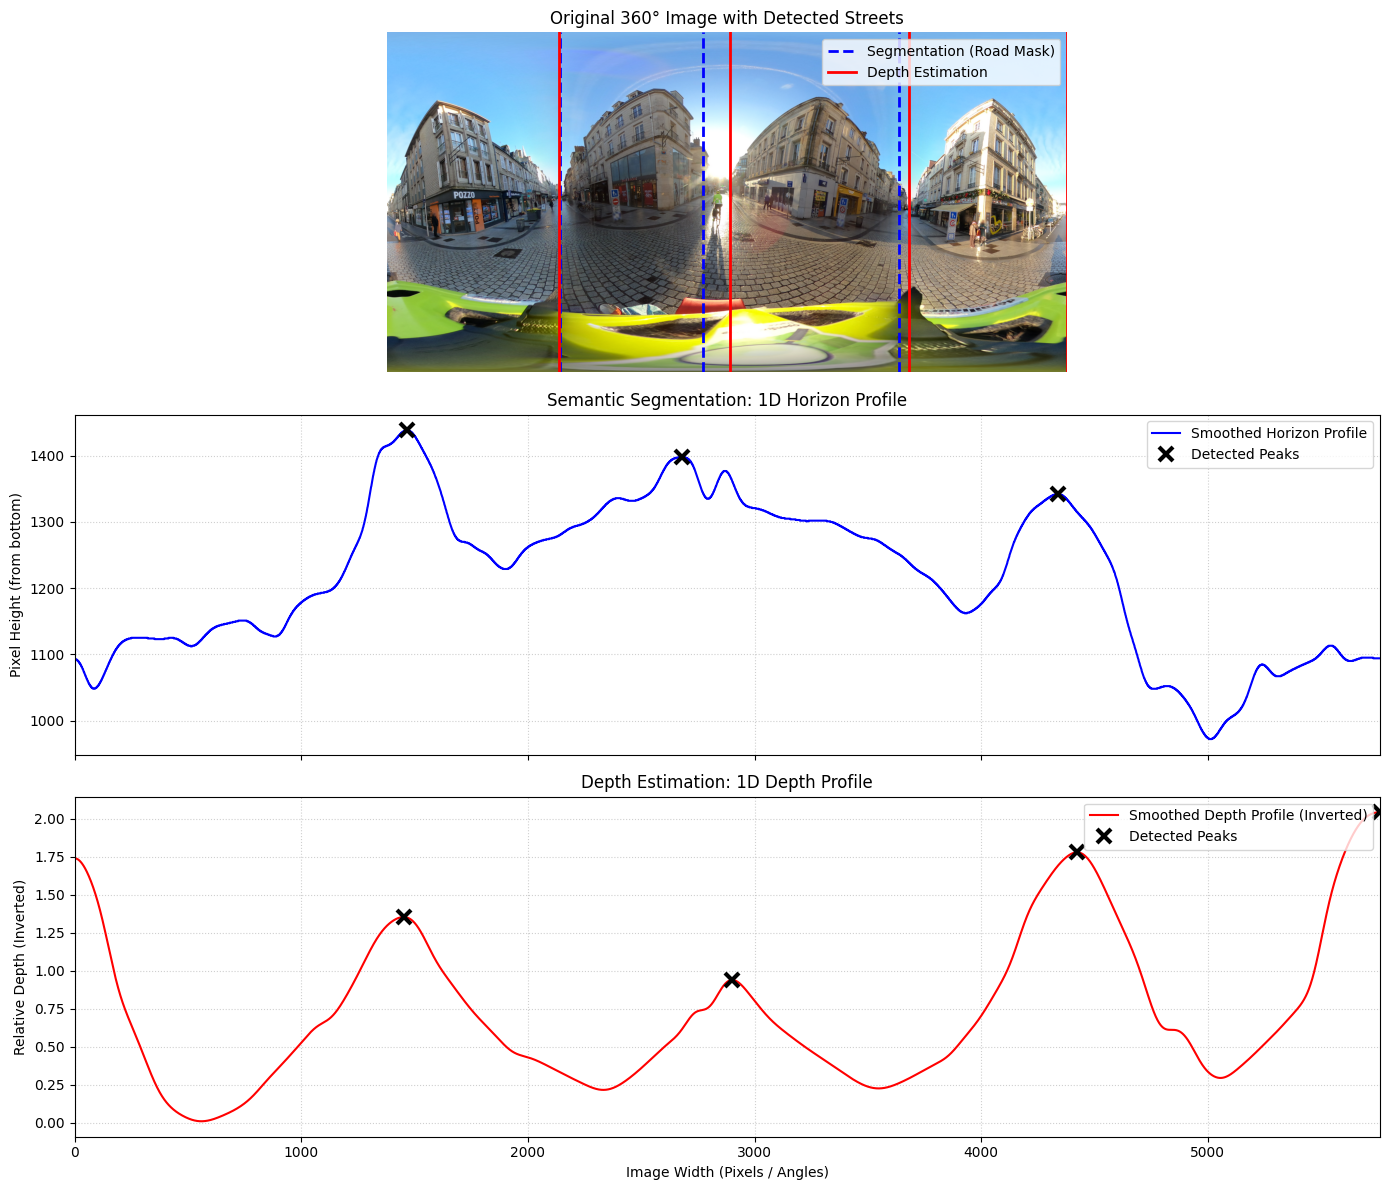

In [89]:
panorama_path = "./streetview_panoramas/cc6b8656-d52e-42d1-ab10-542588c9f9f0.jpg"
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

In [5]:
panorama_path = "./streetview_panoramas/9e56e68c-937e-4d55-8e4b-db6e84e3beb0.jpg"
image = cv2.imread(panorama_path)
seg_mask = segmentation_model.predict(image)
depth_map = depth_model.predict(image)
compare_street_detection(image, seg_mask, depth_map)

NameError: name 'compare_street_detection' is not defined

- depth estimation with depth anything aligns much better with the streets than
the nvidia/segformer-b2-finetuned-cityscapes-1024-1024 segmentation model

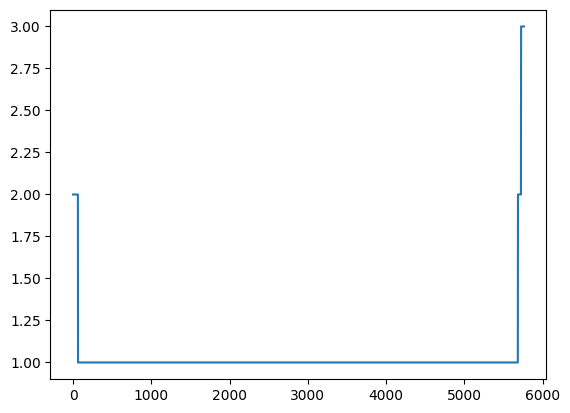

In [13]:
angles = find_street_angles(depth_map)
# street_images = extract_street_views(image, angles)
# display_extracted_streets(street_images, angles)

# Execution

In [8]:
import os
import cv2

p = "./streetview_panoramas"
out_dir = "./outputs"
os.makedirs(out_dir, exist_ok=True)
for e in os.scandir(p):
    if e.is_file() and e.name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img = cv2.imread(e.path)
        if img is None: continue

        depth_map = depth_model.predict(img) 
        angles = find_street_angles(depth_map)
        street_images = extract_street_views(img, angles)
        base_name = os.path.splitext(e.name)[0]
        for counter, crop in enumerate(street_images):
            file_name = f"{base_name}_{counter}.jpg"
            output_path = os.path.join(out_dir, file_name)
            cv2.imwrite(output_path, crop)

Found 3 street entrances at angles: [np.float64(-79.31250000000001), np.float64(45.62500000000003), np.float64(97.9375)]
Found 4 street entrances at angles: [np.float64(-57.5), np.float64(12.0), np.float64(69.68749999999997), np.float64(127.0)]
Found 3 street entrances at angles: [np.float64(51.6875), np.float64(113.0), np.float64(179.9375)]
Found 1 street entrances at angles: [np.float64(-2.125)]
Found 3 street entrances at angles: [np.float64(-151.6875), np.float64(37.5625), np.float64(157.875)]
Found 1 street entrances at angles: [np.float64(98.25)]
Found 3 street entrances at angles: [np.float64(39.0625), np.float64(101.625), np.float64(164.8125)]
Found 4 street entrances at angles: [np.float64(-89.25), np.float64(1.3125), np.float64(96.4375), np.float64(179.9375)]
Found 4 street entrances at angles: [np.float64(-92.0), np.float64(5.499999999999972), np.float64(50.4375), np.float64(112.625)]
Found 2 street entrances at angles: [np.float64(-172.875), np.float64(8.0)]
Found 2 street 

# Benchmark

- first execute annotate_panorama.py (edit paths if necessary) to create ground_truth.json
- then simply execute the code block below to receive precision, recall, f1-score, mean angular error


In [2]:
import json
from cropping_tests import *
from cropping_panorama import *
depth_model = DepthEstimationModel()

# Load the dataset you just clicked through
with open('ground_truth.json', 'r') as f:
    benchmark_dataset = json.load(f)

# Run your evaluation!
metrics = run_benchmark(benchmark_dataset, depth_model, tolerance=15.0)

Using Apple Silicon MPS for Depth Estimation.


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 2224.38it/s, Materializing param=neck.reassemble_stage.layers.3.resize.weight]                  


Starting benchmark on 15 images with a tolerance of 15.0°...
Processing ./streetview_panoramas/9e56e68c-937e-4d55-8e4b-db6e84e3beb0.jpg...
  -> Predicted: [np.float64(-79.31250000000001), np.float64(45.62500000000003), np.float64(97.9375)]
  -> True:      [-80.55, 46.80000000000001, 101.92500000000001]
  -> Image Stats: TP=3, FP=0, FN=0
Processing ./streetview_panoramas/test10.jpg...
  -> Predicted: [np.float64(-57.5), np.float64(12.0), np.float64(69.68749999999997), np.float64(127.0)]
  -> True:      [-123.3, -47.92500000000001, 136.8]
  -> Image Stats: TP=2, FP=2, FN=1
Processing ./streetview_panoramas/test6.jpg...
  -> Predicted: [np.float64(51.6875), np.float64(113.0), np.float64(179.9375)]
  -> True:      [-145.35, -71.775, 26.099999999999994, 110.69999999999999]
  -> Image Stats: TP=1, FP=2, FN=3
Processing ./streetview_panoramas/6f34a62d-c8be-429d-b266-b1aca354ae1d.jpg...
  -> Predicted: [np.float64(-2.125)]
  -> True:      [-174.825, -59.175, -4.5, 177.3]
  -> Image Stats: TP=1

- the cropping according to depth works best if the following criteria are met at the strestreetview panorama:
- it should be
  - in a city (with walls to all sides)
  - in the center of an interception (not at a sidewalk)
  - made with a perfectly horizontal camera